In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
pima = pd.read_csv("Pima Indians Diabetes.csv")
brfss = pd.read_csv("BRFSS Diabetes Indicators.csv")
diabd = pd.read_csv("DiaBD_A Diabetes Dataset for Enhanced Risk Analysis and Research in Bangladesh.csv")

In [40]:
print("Pima columns:", pima.columns)
print("BRFSS columns:", brfss.columns)
print("DiaBD columns:", diabd.columns)

print(pima.head())
print(brfss.head())
print(diabd.head())

Pima columns: Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')
BRFSS columns: Index(['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')
DiaBD columns: Index(['age', 'gender', 'pulse_rate', 'systolic_bp', 'diastolic_bp', 'glucose',
       'height', 'weight', 'bmi', 'family_diabetes', 'hypertensive',
       'family_hypertension', 'cardiovascular_disease', 'stroke', 'diabetic'],
      dtype='object')
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.

**The combined dataset was created from three public diabetes datasets.
The data collection method is retrospective observational because the data was collected from existing medical records, surveys, or patient measurements without applying any experimental treatment.**

In [41]:
# 2) Prepare Pima dataset

pima = pima[['Age', 'BMI', 'Glucose', 'BloodPressure', 'Outcome']].copy()

# Create HighBP from BloodPressure
pima['HighBP'] = np.where(pima['BloodPressure'] >= 90, 1, 0)

# Add Source
pima['Source'] = 'Pima'

In [42]:
# =========================
# 3. Prepare BRFSS dataset
# =========================

brfss = brfss[['Age', 'BMI', 'HighBP', 'Diabetes_012']].copy()

# Convert BRFSS age categories to approximate real ages
age_mapping = {
    1: 21, # 18–24
    2: 27, # 25–29
    3: 32, # 30–34
    4: 37, # 35–39
    5: 42, # 40–44
    6: 47, # 45–49
    7: 52, # 50–54
    8: 57, # 55–59
    9: 62, # 60–64
    10: 67,# 65–69
    11: 72,# 70–74
    12: 77,# 75–79
    13: 82 # 80 or older
}

brfss['Age'] = brfss['Age'].replace(age_mapping)

# Remove prediabetes rows
brfss = brfss[brfss['Diabetes_012'] != 1]

# Convert Diabetes_012 to binary Outcome
brfss['Outcome'] = brfss['Diabetes_012'].replace({
    0: 0,
    2: 1
})

# BRFSS does not have Glucose or BloodPressure
brfss['Glucose'] = np.nan
brfss['BloodPressure'] = np.nan

# Add Source
brfss['Source'] = 'BRFSS'

# Keep needed columns only
brfss = brfss[
    ['Age', 'BMI', 'Glucose', 'BloodPressure', 'HighBP', 'Outcome', 'Source']
]

In [43]:
diabd = diabd[['age', 'bmi', 'glucose', 'diastolic_bp', 'diabetic']].copy()

# Rename columns
diabd = diabd.rename(columns={
    'age': 'Age',
    'bmi': 'BMI',
    'glucose': 'Glucose',
    'diastolic_bp': 'BloodPressure',
    'diabetic': 'Outcome'
})

# Convert diabetic to binary
diabd['Outcome'] = diabd['Outcome'].replace({
    'Yes': 1,
    'No': 0,
    'yes': 1,
    'no': 0,
    1: 1,
    0: 0
})

# Create HighBP from BloodPressure
diabd['HighBP'] = np.where(diabd['BloodPressure'] >= 90, 1, 0)

# Add Source
diabd['Source'] = 'DiaBD_A'

/tmp/ipykernel_29633/3502417515.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  diabd['Outcome'] = diabd['Outcome'].replace({


In [44]:
final_columns = [
    'Age',
    'BMI',
    'Glucose',
    'BloodPressure',
    'HighBP',
    'Outcome',
    'Source'
]

pima = pima[final_columns]
brfss = brfss[final_columns]
diabd = diabd[final_columns]

In [45]:
# combine dataset

combined = pd.concat(
    [pima, brfss, diabd],
    ignore_index=True
)

In [46]:
numeric_columns = [
    'Age',
    'BMI',
    'Glucose',
    'BloodPressure',
    'HighBP',
    'Outcome'
]

for col in numeric_columns:
    combined[col] = pd.to_numeric(combined[col], errors='coerce')

In [47]:
combined = combined.dropna(subset=['Age', 'BMI', 'HighBP', 'Outcome'])

In [48]:
# Reset index
combined = combined.reset_index(drop=True)
# 9. Save final dataset
combined.to_csv("combined_diabetes_dataset.csv", index=False)

In [49]:
print(combined.head())
print(combined.shape)
print(combined.info())
print(combined['Source'].value_counts())
print(combined.isnull().sum())

    Age   BMI  Glucose  BloodPressure  HighBP  Outcome Source
0  50.0  33.6    148.0           72.0     0.0      1.0   Pima
1  31.0  26.6     85.0           66.0     0.0      0.0   Pima
2  32.0  23.3    183.0           64.0     0.0      1.0   Pima
3  21.0  28.1     89.0           66.0     0.0      0.0   Pima
4  33.0  43.1    137.0           40.0     0.0      1.0   Pima
(255105, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255105 entries, 0 to 255104
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Age            255105 non-null  float64
 1   BMI            255105 non-null  float64
 2   Glucose        6056 non-null    float64
 3   BloodPressure  6056 non-null    float64
 4   HighBP         255105 non-null  float64
 5   Outcome        255105 non-null  float64
 6   Source         255105 non-null  object 
dtypes: float64(6), object(1)
memory usage: 13.6+ MB
None
Source
BRFSS      249049
DiaBD_A      5288


Numerical summaries were calculated to understand the central tendency and variability of the combined diabetes dataset. The mean, variance, and standard deviation were computed for Age, BMI, Glucose, BloodPressure, HighBP, and Outcome.

In [50]:
# =========================
# Missing Values Check
# =========================

print("===== Missing Values =====")
print(combined.isnull().sum())
print("======================")
print("""Glucose and BloodPressure were missing for BRFSS records because these variables do not exist in the original BRFSS dataset.
These missing values were preserved to avoid introducing artificial medical measurements.""")

===== Missing Values =====
Age                   0
BMI                   0
Glucose          249049
BloodPressure    249049
HighBP                0
Outcome               0
Source                0
dtype: int64
Glucose and BloodPressure were missing for BRFSS records because these variables do not exist in the original BRFSS dataset.
These missing values were preserved to avoid introducing artificial medical measurements.


In [51]:
# Full dataset analysis variables
full_analysis_cols = ['Age', 'BMI', 'HighBP', 'Outcome']

full_data = combined[full_analysis_cols]

print("Full dataset columns:")
print(full_data.head())
print(full_data.isnull().sum())

Full dataset columns:
    Age   BMI  HighBP  Outcome
0  50.0  33.6     0.0      1.0
1  31.0  26.6     0.0      0.0
2  32.0  23.3     0.0      1.0
3  21.0  28.1     0.0      0.0
4  33.0  43.1     0.0      1.0
Age        0
BMI        0
HighBP     0
Outcome    0
dtype: int64


In [52]:
# Glucose and BloodPressure analysis only from Pima and DiaBD_A
medical_measurements = combined[
    combined['Source'].isin(['Pima', 'DiaBD_A'])
].copy()

medical_cols = ['Age', 'BMI', 'Glucose', 'BloodPressure', 'HighBP', 'Outcome', 'Source']

medical_measurements = medical_measurements[medical_cols]

print("Pima + DiaBD_A medical measurements:")
print(medical_measurements.head())
print(medical_measurements.isnull().sum())
print(medical_measurements['Source'].value_counts())

Pima + DiaBD_A medical measurements:
    Age   BMI  Glucose  BloodPressure  HighBP  Outcome Source
0  50.0  33.6    148.0           72.0     0.0      1.0   Pima
1  31.0  26.6     85.0           66.0     0.0      0.0   Pima
2  32.0  23.3    183.0           64.0     0.0      1.0   Pima
3  21.0  28.1     89.0           66.0     0.0      0.0   Pima
4  33.0  43.1    137.0           40.0     0.0      1.0   Pima
Age              0
BMI              0
Glucose          0
BloodPressure    0
HighBP           0
Outcome          0
Source           0
dtype: int64
Source
DiaBD_A    5288
Pima        768
Name: count, dtype: int64


In [53]:
print("===== Full Dataset Summary =====")
print(full_data.mean())
print(full_data.var())
print(full_data.std())

print("\n===== Pima + DiaBD_A Summary =====")
print(medical_measurements[['Glucose', 'BloodPressure']].mean())
print(medical_measurements[['Glucose', 'BloodPressure']].var())
print(medical_measurements[['Glucose', 'BloodPressure']].std())

===== Full Dataset Summary =====
Age        56.734290
BMI        28.228089
HighBP      0.420878
Outcome     0.140946
dtype: float64
Age        238.235861
BMI         44.990832
HighBP       0.243741
Outcome      0.121081
dtype: float64
Age        15.434891
BMI         6.707521
HighBP      0.493701
Outcome     0.347966
dtype: float64

===== Pima + DiaBD_A Summary =====
Glucose          21.936100
BloodPressure    80.565225
dtype: float64
Glucose          1559.543241
BloodPressure     202.507388
dtype: float64
Glucose          39.491053
BloodPressure    14.230509
dtype: float64


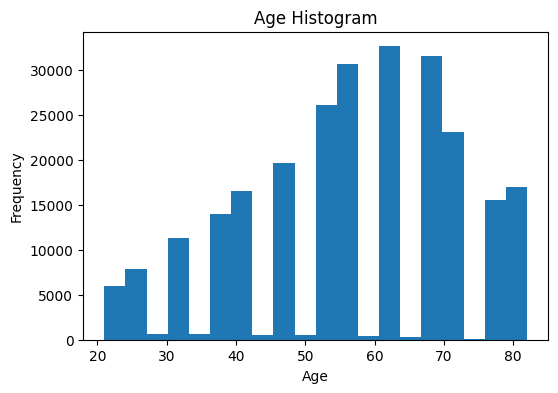

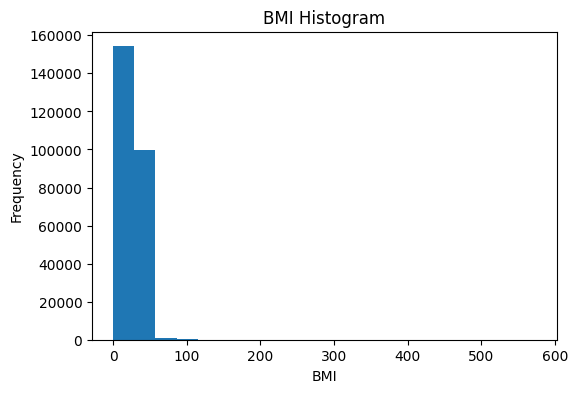

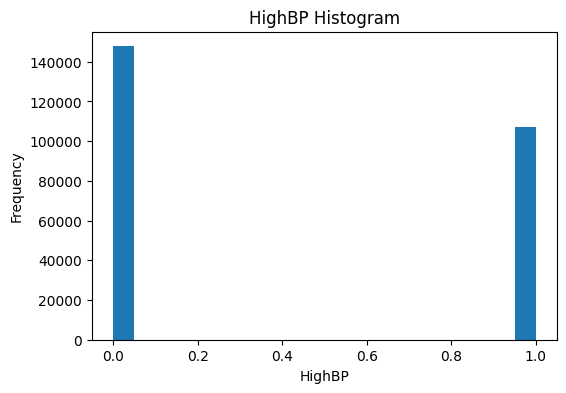

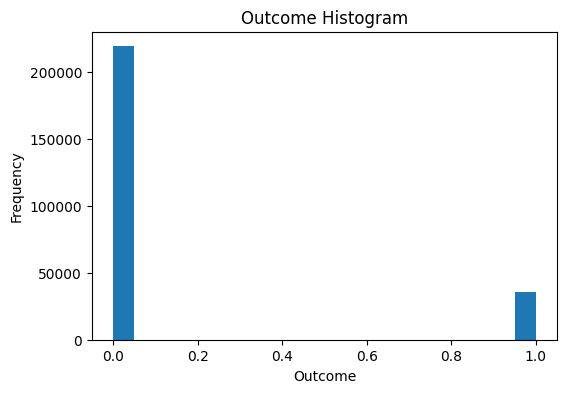

In [54]:
import matplotlib.pyplot as plt

# Variables to visualize
columns = ['Age', 'BMI', 'HighBP', 'Outcome']

for col in columns:
    plt.figure(figsize=(6,4))
    plt.hist(full_data[col], bins=20)
    plt.title(f'{col} Histogram')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

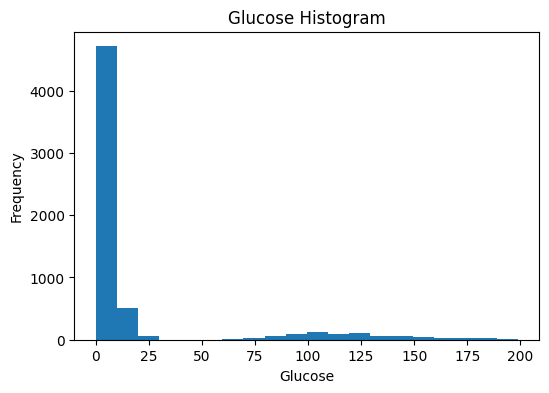

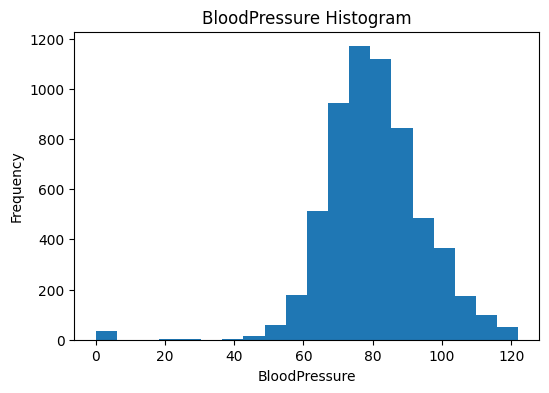

In [55]:
columns = ['Glucose', 'BloodPressure']

for col in columns:
    plt.figure(figsize=(6,4))
    plt.hist(medical_measurements[col], bins=20)
    plt.title(f'{col} Histogram')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

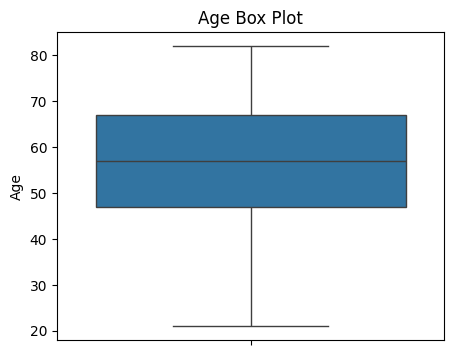

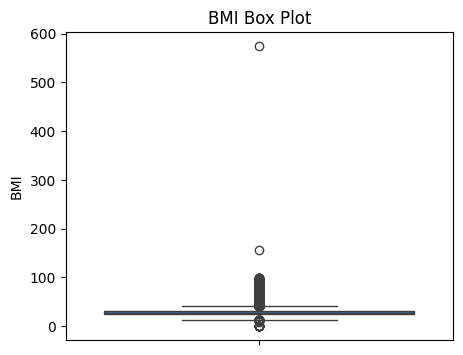

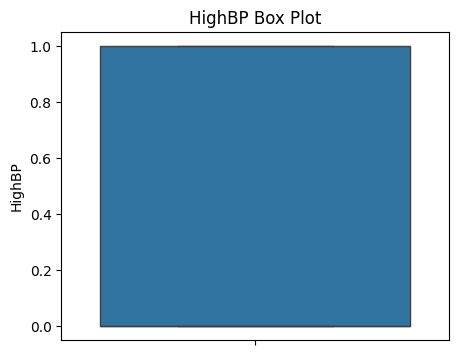

In [56]:
import seaborn as sns

columns = ['Age', 'BMI', 'HighBP']

for col in columns:
    plt.figure(figsize=(5,4))
    sns.boxplot(y=full_data[col])
    plt.title(f'{col} Box Plot')
    plt.show()

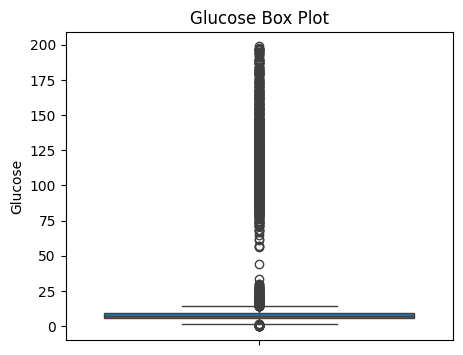

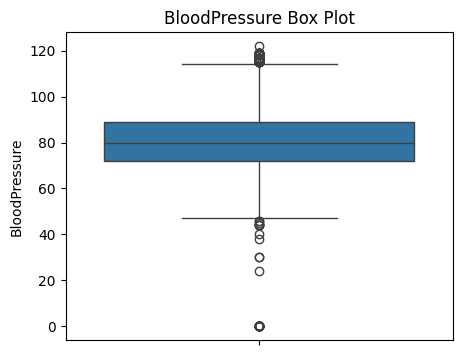

In [57]:
columns = ['Glucose', 'BloodPressure']

for col in columns:
    plt.figure(figsize=(5,4))
    sns.boxplot(y=medical_measurements[col])
    plt.title(f'{col} Box Plot')
    plt.show()

In [58]:
# Stem-and-Leaf Plot for BMI using sample to avoid huge output

bmi_values = full_data['BMI'].dropna().astype(int).sample(1000, random_state=42)

stems = {}

for value in bmi_values:
    stem = value // 10
    leaf = value % 10

    if stem not in stems:
        stems[stem] = []

    stems[stem].append(leaf)

print("Stem-and-Leaf Plot for BMI Sample\n")

for stem, leaves in sorted(stems.items()):
    leaves.sort()
    print(f"{stem} | {' '.join(map(str, leaves))}")

Stem-and-Leaf Plot for BMI Sample

1 | 1 4 5 6 6 6 7 7 8 8 8 8 8 8 8 8 9 9 9 9 9 9 9 9
2 | 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7

2. Statistical Inference:
a) Perform hypothesis testing to determine if specific factors (e.g., temperature, pressure, or material type) significantly affect the output.
b) Construct confidence intervals for the mean and variance to quantify the risks in the engineering decisions.

In [59]:
 from scipy.stats import ttest_ind, chi2_contingency

# Split full dataset by outcome
diabetic = full_data[full_data['Outcome'] == 1]
non_diabetic = full_data[full_data['Outcome'] == 0]

# T-test: BMI
t_stat, p_value = ttest_ind(
    diabetic['BMI'],
    non_diabetic['BMI'],
    nan_policy='omit'
)

print("BMI t-test")
print("t-statistic:", t_stat)
print("p-value:", p_value)


# T-test: Age
t_stat, p_value = ttest_ind(
    diabetic['Age'],
    non_diabetic['Age'],
    nan_policy='omit'
)

print("\nAge t-test")
print("t-statistic:", t_stat)
print("p-value:", p_value)


# Chi-square test: HighBP vs Outcome
contingency_table = pd.crosstab(full_data['HighBP'], full_data['Outcome'])

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("\nHighBP Chi-square test")
print("Chi-square:", chi2)
print("p-value:", p_value)

BMI t-test
t-statistic: 114.57561700688161
p-value: 0.0

Age t-test
t-statistic: 92.01982005199477
p-value: 0.0

HighBP Chi-square test
Chi-square: 18106.1910164049
p-value: 0.0


In [65]:
# Use only Pima + DiaBD_A
diabetic_med = medical_measurements[medical_measurements['Outcome'] == 1]
non_diabetic_med = medical_measurements[medical_measurements['Outcome'] == 0]

# T-test: Glucose
t_stat, p_value = ttest_ind(
    diabetic_med['Glucose'],
    non_diabetic_med['Glucose'],
    nan_policy='omit'
)

print("Glucose t-test")
print("t-statistic:", t_stat)
print("p-value:", p_value)


# T-test: BloodPressure
t_stat, p_value = ttest_ind(
    diabetic_med['BloodPressure'],
    non_diabetic_med['BloodPressure'],
    nan_policy='omit'
)

print("\nBloodPressure t-test")
print("t-statistic:", t_stat)
print("p-value:", p_value)
print("============================================")

print("""The hypothesis testing results show that BMI, Age, HighBP, and Glucose have statistically significant
relationships with diabetes outcome because their p-values are less than 0.05.
However, BloodPressure was not statistically significant because its p-value was greater than 0.05.
Therefore, BMI, Age, HighBP, and Glucose are considered important factors for diabetes risk in this analysis.
""")

Glucose t-test
t-statistic: 33.18153288374212
p-value: 5.666850440786158e-222

BloodPressure t-test
t-statistic: 1.467939552190261
p-value: 0.14217259374930394
The hypothesis testing results show that BMI, Age, HighBP, and Glucose have statistically significant 
relationships with diabetes outcome because their p-values are less than 0.05. 
However, BloodPressure was not statistically significant because its p-value was greater than 0.05. 
Therefore, BMI, Age, HighBP, and Glucose are considered important factors for diabetes risk in this analysis.



2b) Confidence Intervals


In [66]:
import numpy as np
from scipy import stats

def mean_confidence_interval(data, confidence=0.95):
    data = data.dropna()
    n = len(data)
    mean = np.mean(data)
    sem = stats.sem(data)
    margin = sem * stats.t.ppf((1 + confidence) / 2., n-1)
    return mean, mean - margin, mean + margin

In [67]:
for col in ['Age', 'BMI']:
    mean, lower, upper = mean_confidence_interval(full_data[col])
    print(f"{col} 95% CI for mean:")
    print("Mean:", mean)
    print("Lower:", lower)
    print("Upper:", upper)
    print()

Age 95% CI for mean:
Mean: 56.734289802238294
Lower: 56.674394296836454
Upper: 56.794185307640134

BMI 95% CI for mean:
Mean: 28.228088747770528
Lower: 28.202060035787824
Upper: 28.254117459753232



In [69]:
for col in ['Age', 'BMI', 'HighBP']:
    mean, lower, upper = mean_confidence_interval(full_data[col])

    print(f"{col} 95% CI for mean:")
    print("Mean:", mean)
    print("Lower:", lower)
    print("Upper:", upper)
    print()

Age 95% CI for mean:
Mean: 56.734289802238294
Lower: 56.674394296836454
Upper: 56.794185307640134

BMI 95% CI for mean:
Mean: 28.228088747770528
Lower: 28.202060035787824
Upper: 28.254117459753232

HighBP 95% CI for mean:
Mean: 0.4208776778189373
Lower: 0.4189618582004637
Upper: 0.4227934974374109



In [68]:
#Confidence intervals for medical measurements
for col in ['Glucose', 'BloodPressure']:
    mean, lower, upper = mean_confidence_interval(medical_measurements[col])
    print(f"{col} 95% CI for mean:")
    print("Mean:", mean)
    print("Lower:", lower)
    print("Upper:", upper)
    print()

Glucose 95% CI for mean:
Mean: 21.936099735799207
Lower: 20.9412884813859
Upper: 22.930910990212514

BloodPressure 95% CI for mean:
Mean: 80.5652245706737
Lower: 80.20674664666943
Upper: 80.92370249467798



In [75]:
#Confidence Interval for Variance
def variance_confidence_interval(data, confidence=0.95):
    data = data.dropna()
    n = len(data)
    sample_variance = np.var(data, ddof=1)

    alpha = 1 - confidence

    lower = (n - 1) * sample_variance / stats.chi2.ppf(1 - alpha/2, n - 1)
    upper = (n - 1) * sample_variance / stats.chi2.ppf(alpha/2, n - 1)

    return sample_variance, lower, upper

In [76]:
for col in ['Age', 'BMI']:
    var, lower, upper = variance_confidence_interval(full_data[col])
    print(f"{col} 95% CI for variance:")
    print("Variance:", var)
    print("Lower:", lower)
    print("Upper:", upper)
    print()

Age 95% CI for variance:
Variance: 238.2358610603254
Lower: 236.933838554782
Upper: 239.5486953943358

BMI 95% CI for variance:
Variance: 44.99083186790322
Lower: 44.744944975080244
Upper: 45.238760574055966



In [77]:
for col in ['Age', 'BMI', 'HighBP']:
    var, lower, upper = variance_confidence_interval(full_data[col])
    print(f"{col} 95% CI for variance:")
    print("Variance:", var)
    print("Lower:", lower)
    print("Upper:", upper)
    print()

Age 95% CI for variance:
Variance: 238.2358610603254
Lower: 236.933838554782
Upper: 239.5486953943358

BMI 95% CI for variance:
Variance: 44.99083186790322
Lower: 44.744944975080244
Upper: 45.238760574055966

HighBP 95% CI for variance:
Variance: 0.2437406135848358
Lower: 0.24240850613892087
Upper: 0.24508378268071723



In [78]:
for col in ['Glucose', 'BloodPressure']:
    var, lower, upper = variance_confidence_interval(medical_measurements[col])
    print(f"{col} 95% CI for variance:")
    print("Variance:", var)
    print("Lower:", lower)
    print("Upper:", upper)
    print()

Glucose 95% CI for variance:
Variance: 1559.5432406731254
Lower: 1505.4482652934432
Upper: 1616.6214858707817

BloodPressure 95% CI for variance:
Variance: 202.50738832280285
Lower: 195.48313154054298
Upper: 209.91902402713703



Hypothesis testing was performed to determine whether BMI, Age, HighBP, Glucose, and BloodPressure significantly differ between diabetic and non-diabetic patients. Confidence intervals were constructed for the mean and variance to quantify uncertainty and variability in the selected health indicators.